# BN-SCM A/T/N Causal Ordering Experiments

This notebook analyzes the dynamic Bayesian-network structural causal model experiment built from ADNI rate targets. The central question is not only prediction accuracy, but event ordering: whether baseline amyloid, tau, neurodegeneration/atrophy, and fluid biomarkers explain future rates of change in downstream systems.

The figures are generated by `run_causal_ordering_experiments.py` and loaded here so the notebook stays reproducible without rerunning the full model every time.

## Mathematical Model

For a subject `i`, modality/region `j`, baseline scan time `t0`, and follow-up scan time `t1`, the target is an annualized source-specific rate:

$$R_{ij}=\frac{Y_{ij}(t_1)-Y_{ij}(t_0)}{t_1-t_0}.$$

The latent disease coordinate `Z_i` is estimated from train-only, tau-free multimodal baseline features and oriented so larger values represent more severe disease burden. The dynamic SCM then models future rate targets as varying-coefficient structural equations:

$$R_{ij}=a_j(Z_i)+c_j(Z_i)Y_{ij}(t_0)+\sum_{\ell \in \mathcal{P}_j} b_{j\ell}(Z_i)X_{i\ell}(t_0)+\epsilon_{ij}, \quad \epsilon_{ij}\sim\mathcal{N}(0,\sigma_j^2).$$

`a_j(Z)` captures the disease-stage baseline rate, `c_j(Z)` captures self-history dependence, and `b_{j\ell}(Z)` captures a candidate directed baseline-to-future-rate effect. Coefficients are represented with spline bases and ridge regularization. An edge is treated as active when its absolute standardized effect exceeds `0.05` target standard deviations per predictor standard deviation.

## Hypotheses Tested

1. **Atrophy-gated tau ignition:** amyloid-by-neurodegeneration interaction terms should explain future tau rates if structural vulnerability gates tau acceleration.
2. **Amyloid-to-tau early, tau-self late phase switch:** amyloid effects should dominate early pseudotime, while tau self-history should strengthen late.
3. **Tau-to-atrophy versus atrophy-to-tau:** baseline tau should explain future atrophy more strongly than baseline atrophy explains future tau if tau is the more directional injury driver.
4. **Amyloid permissive versus directly neurodegenerative:** amyloid should explain future tau more strongly than future atrophy if it acts mainly as a permissive upstream pathology.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Markdown, SVG, display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "BayesianNetwork-SCM":
    PROJECT_DIR = NOTEBOOK_DIR
elif (NOTEBOOK_DIR / "BayesianNetwork-SCM").exists():
    PROJECT_DIR = NOTEBOOK_DIR / "BayesianNetwork-SCM"
else:
    PROJECT_DIR = Path("BayesianNetwork-SCM").resolve()

sys.path.insert(0, str(PROJECT_DIR))
OUTPUT_DIR = PROJECT_DIR / "outputs" / "causal_ordering"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_PATH = OUTPUT_DIR / "causal_ordering_report.json"

# Set True to rebuild the dataset, refit the model, and regenerate all tables/figures.
RUN_FULL_EXPERIMENTS = False

if RUN_FULL_EXPERIMENTS or not REPORT_PATH.exists():
    from run_causal_ordering_experiments import run_causal_ordering_experiments
    report = run_causal_ordering_experiments(output_dir=OUTPUT_DIR)
else:
    report = json.loads(REPORT_PATH.read_text())

tables = {name: pd.read_csv(path) for name, path in report["tables"].items()}
figures = {name: Path(path) for name, path in report["figures"].items()}
display(Markdown(f"Loaded report from `{REPORT_PATH}`"))

Loaded report from `/Users/nguyenlinhda/Downloads/SPREAD-TOOLBOX/BayesianNetwork-SCM/outputs/causal_ordering/causal_ordering_report.json`

In [2]:
dataset = report["dataset"]
split = report["split"]
pseudotime = report["pseudotime"]

summary_md = f"""
### Experiment Summary

- Pairs: **{dataset['pairs']}** across **{dataset['subjects']}** subjects
- Features: **{dataset['feature_count']}**; rate targets: **{dataset['target_count']}**; fitted targets: **{dataset['fit_target_count']}**
- Train/validation/test pairs: **{split['train_pairs']} / {split['validation_pairs']} / {split['test_pairs']}**
- Tau-free pseudotime selected features: **{pseudotime['selected_feature_count']}**; explained variance ratio: **{pseudotime['explained_variance_ratio']:.3f}**
- Activation threshold: **{report['activation_threshold']:.3f}** standardized effect
"""
display(Markdown(summary_md))
display(pd.DataFrame(dataset["rows"].items(), columns=["row_or_match_type", "count"]))


### Experiment Summary

- Pairs: **796** across **541** subjects
- Features: **73**; rate targets: **54**; fitted targets: **54**
- Train/validation/test pairs: **473 / 167 / 156**
- Tau-free pseudotime selected features: **59**; explained variance ratio: **0.272**
- Activation threshold: **0.050** standardized effect


,row_or_match_type,count
0,all_cortical_modalities,179
1,all_main_modalities,392
2,amyloid,590
3,foxlab_bsi,615
4,fsx6,348
5,input_pairs,796
6,picsl_ashs,590
7,unique_subjects,541
8,usable_pairs,796


## Dataset Coverage

This panel checks whether the experiment is supported by enough matched longitudinal data. Amyloid, FOXLAB/PICSL structural MRI, FreeSurfer cortical measures, tau-PET, and cognition are not all observed at identical dates; therefore non-tau rates use their own nearest matched source intervals.

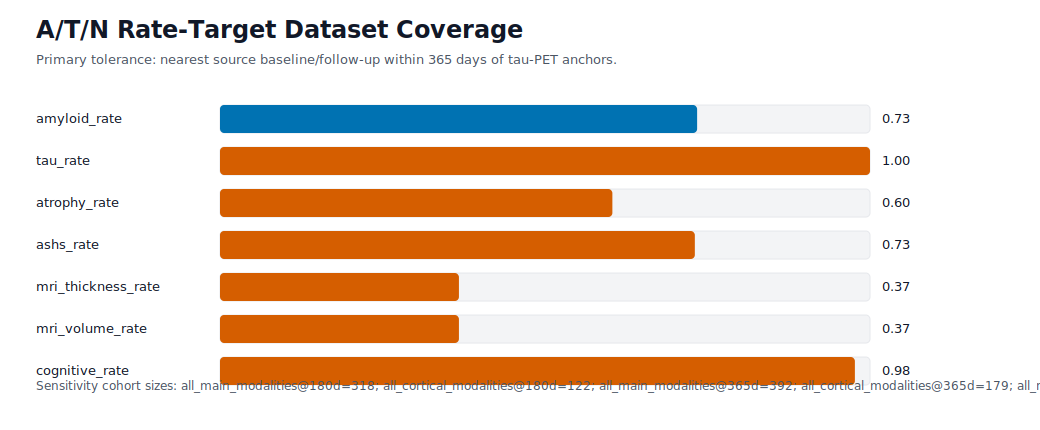

tolerance_days,180,365,730
name,,,
all_cortical_modalities,122,179,236
all_main_modalities,318,392,450
amyloid,517,590,620
foxlab_bsi,575,615,648
fsx6,324,348,398
picsl_ashs,557,590,632


In [3]:
display(SVG(filename=str(figures["coverage"])))
coverage = tables["dataset_sensitivity"]
coverage.query("group == 'matched_modalities'").pivot(index="name", columns="tolerance_days", values="finite_rows")

## Causal Event Ordering

The event timeline asks which directed pathway becomes active first along pseudotime. This is the main causal-ordering result for questions such as whether amyloid precedes tau, whether tau precedes atrophy, and whether atrophy feeds back into future tau acceleration.

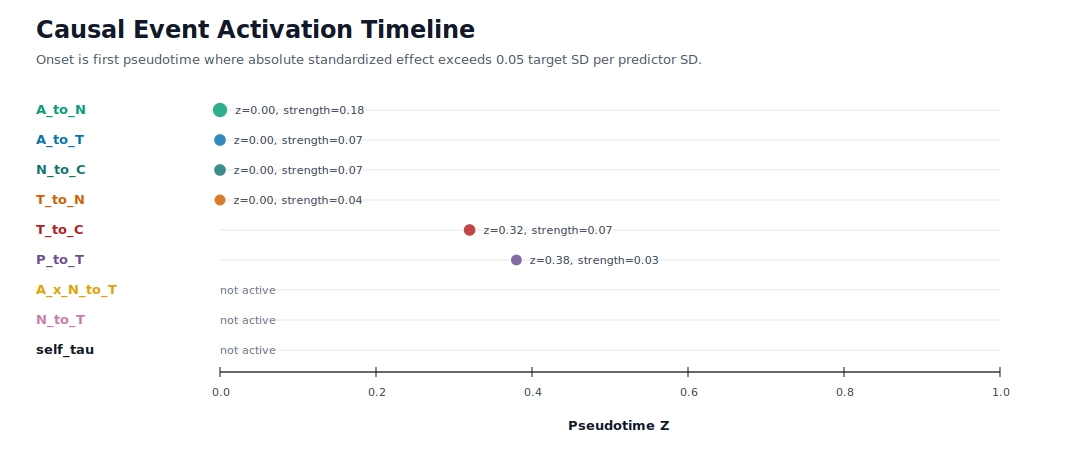

,pathway,active_edge_count,earliest_onset_z,mean_max_abs_std_effect,top_parent,top_target,top_max_abs_std_effect
0,A_to_N,35,0.00,0.179841,amyloid_centiloids,ashs_rate:right_ba36,1.488744
1,A_to_T,11,0.00,0.069493,plasma_ab42_ab40,tau_rate:R_inferiortemporal,0.757644
2,N_to_C,7,0.00,0.068797,plasma_nfl,cognitive_rate:mmse,0.184096
3,T_to_N,7,0.00,0.037294,tau_meta_temporal,ashs_rate:right_phc,0.132465
4,T_to_C,4,0.32,0.066502,tau_region:R_inferiortemporal,cognitive_rate:mmse,0.163345
5,P_to_T,1,0.38,0.032410,plasma_pt217,tau_rate:R_inferiortemporal,0.146750
6,A_x_N_to_T,0,NaN,0.026448,interaction:amyloid_centiloids_x_mri_hippocamp...,tau_rate:R_middletemporal,0.046175
7,N_to_T,0,NaN,0.008320,mri_hippocampus_vulnerability,tau_rate:R_inferiortemporal,0.049638
8,self_tau,0,NaN,0.007928,self_history,tau_rate:R_inferiortemporal,0.024057


In [4]:
display(SVG(filename=str(figures["event_timeline"])))
pathways = tables["pathway_summary"].copy()
pathways[["pathway", "active_edge_count", "earliest_onset_z", "mean_max_abs_std_effect", "top_parent", "top_target", "top_max_abs_std_effect"]]

## Particle View of Active Edges

Each particle is an active directed edge. Position is onset pseudotime, color is pathway type, and size is standardized effect strength. This view is useful for seeing whether a claimed cascade is broad and distributed or driven by only one or two edges.

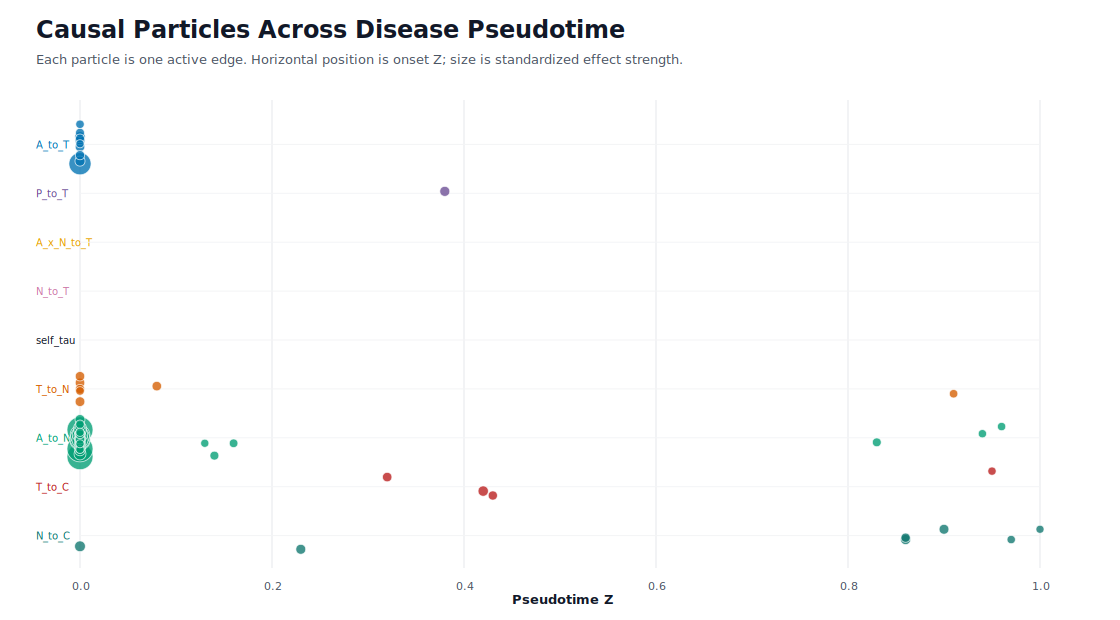

,pathway,parent,target,onset_z,max_abs_std_effect,abs_effect_early,abs_effect_middle,abs_effect_late
5,A_to_N,amyloid_centiloids,ashs_rate:right_ba36,0.0,1.488744,0.342586,0.116969,0.148294
6,A_to_N,amyloid_centiloids,ashs_rate:right_phc,0.0,1.329783,0.317048,0.023207,0.035136
7,A_to_N,amyloid_centiloids,ashs_rate:right_ba35,0.0,1.225204,0.290349,0.012123,0.083553
18,A_to_T,plasma_ab42_ab40,tau_rate:R_inferiortemporal,0.0,0.757644,0.171184,0.046621,0.436655
23,A_to_N,amyloid_centiloids,mri_thickness_rate:L_entorhinal,0.0,0.672812,0.348673,0.084848,0.015457
26,A_to_N,amyloid_centiloids,mri_volume_rate:L_entorhinal,0.0,0.646297,0.182347,0.060761,0.024691
27,A_to_N,amyloid_centiloids,mri_volume_rate:R_entorhinal,0.0,0.645992,0.161804,0.064526,0.075666
31,A_to_N,amyloid_centiloids,atrophy_rate:ventricle_volume,0.0,0.581097,0.256208,0.029389,0.199104
40,A_to_N,amyloid_centiloids,ashs_rate:right_hippocampus,0.0,0.454988,0.125706,0.010410,0.028937
46,A_to_N,amyloid_centiloids,ashs_rate:right_erc,0.0,0.416010,0.079429,0.111491,0.132275


In [5]:
display(SVG(filename=str(figures["particle_cascade"])))
edges = tables["standardized_edges"]
top_edges = edges.query("pathway != 'other'").sort_values("max_abs_std_effect", ascending=False).head(20)
top_edges[["pathway", "parent", "target", "onset_z", "max_abs_std_effect", "abs_effect_early", "abs_effect_middle", "abs_effect_late"]]

## Stage-Specific Dominance

This heatmap separates early, middle, and late pseudotime. It is the direct check for phase-switch claims such as amyloid-to-tau being early while tau self-history becomes late.

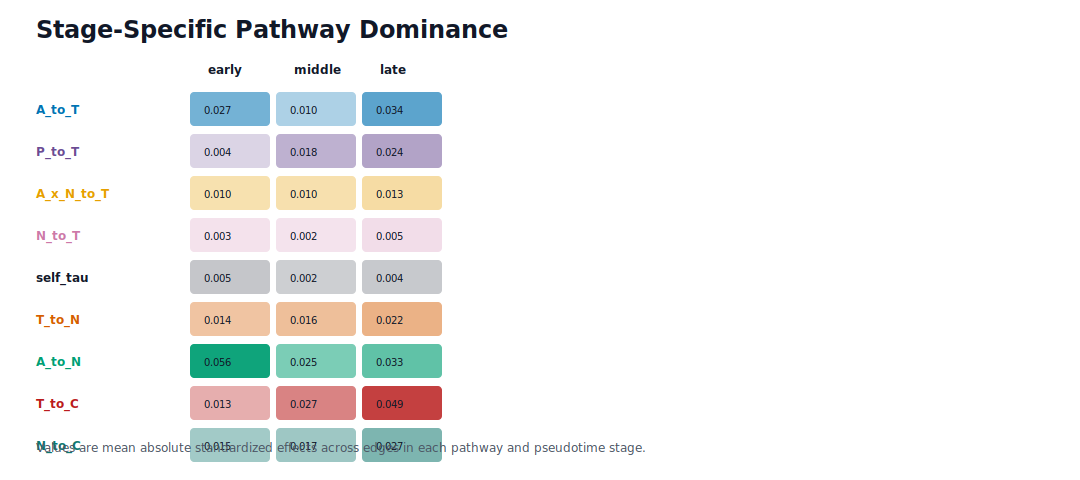

stage,early,late,middle
pathway,,,
A_to_T,0.026942,0.033691,0.010463
P_to_T,0.004469,0.024454,0.018394
A_x_N_to_T,0.009964,0.012946,0.010140
N_to_T,0.002508,0.005344,0.001864
self_tau,0.004855,0.003801,0.002112
T_to_N,0.013681,0.021736,0.015870
A_to_N,0.056021,0.032577,0.024987
T_to_C,0.013188,0.048570,0.026842
N_to_C,0.015024,0.026659,0.016622


In [6]:
display(SVG(filename=str(figures["stage_dominance"])))
stage = tables["stage_dominance"].pivot(index="pathway", columns="stage", values="mean_abs_std_effect")
stage.loc[[p for p in ["A_to_T", "P_to_T", "A_x_N_to_T", "N_to_T", "self_tau", "T_to_N", "A_to_N", "T_to_C", "N_to_C"] if p in stage.index]]

## Brain Maps: Initial, Empirical, Predicted

The brain panel compares the initial regional state, the empirical held-out annualized rate, and the BN-SCM-predicted annualized rate. For thickness, rates are sign-flipped so positive values indicate thinning burden.

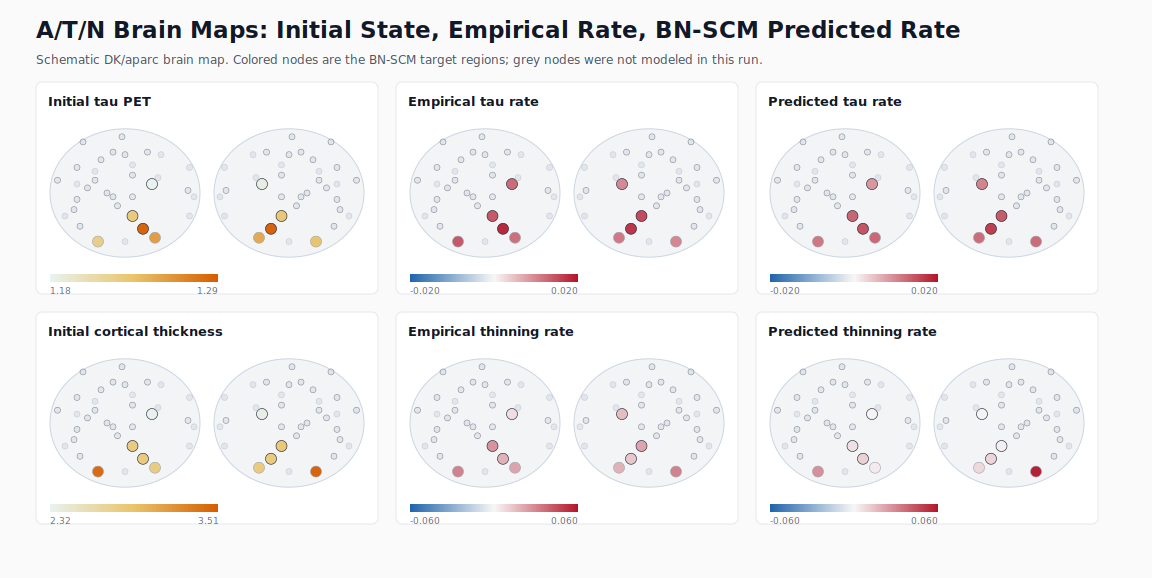

In [7]:
display(SVG(filename=str(figures["brain_empirical_predicted"])))

## Hypothesis Status

These status labels are conservative. `Supported` means the configured effect threshold and directionality comparison are met. `Weak / not confirmed` means the model did not find enough evidence under this version of the dataset and ridge-varying-effect estimator.

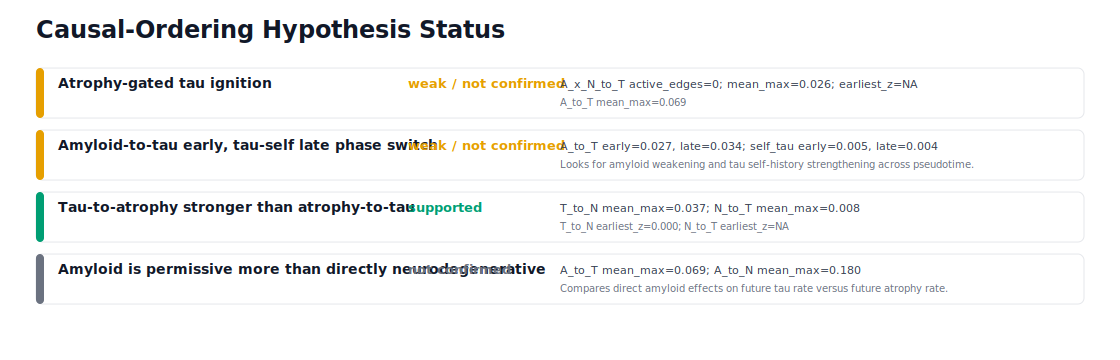

,hypothesis,status,primary_evidence,comparison
0,Atrophy-gated tau ignition,weak / not confirmed,A_x_N_to_T active_edges=0; mean_max=0.026; ear...,A_to_T mean_max=0.069
1,"Amyloid-to-tau early, tau-self late phase switch",weak / not confirmed,"A_to_T early=0.027, late=0.034; self_tau early...",Looks for amyloid weakening and tau self-histo...
2,Tau-to-atrophy stronger than atrophy-to-tau,supported,T_to_N mean_max=0.037; N_to_T mean_max=0.008,T_to_N earliest_z=0.000; N_to_T earliest_z=NA
3,Amyloid is permissive more than directly neuro...,not confirmed,A_to_T mean_max=0.069; A_to_N mean_max=0.180,Compares direct amyloid effects on future tau ...


In [8]:
display(SVG(filename=str(figures["hypothesis_status"])))
hypotheses = tables["hypothesis_tests"]
hypotheses

## Predictive Performance

The model is evaluated on subject-level train/validation/test splits. Because targets have different physical units, the median test MAE and target-wise rank/correlation are more informative than a single pooled error.

In [9]:
metrics = tables["metric_summary"]
display(metrics)
rate_metrics = tables["rate_metrics"]
test_metrics = rate_metrics.query("split == 'test'").sort_values("spearman", ascending=False)
test_metrics[["target", "n", "mae", "rmse", "spearman"]].head(15)

,split,metric,n_targets,mean,median
0,all,mae,54,44.217299,0.239076
1,all,rmse,54,68.338465,0.448917
2,all,pearson,54,0.362922,0.339309
3,all,spearman,54,0.291042,0.296092
4,test,mae,54,49.732719,0.223563
5,test,rmse,54,78.979252,0.395887
6,test,pearson,54,0.228055,0.215392
7,test,spearman,54,0.222196,0.221555
8,train,mae,54,41.226803,0.244204
9,train,rmse,54,63.300221,0.454970


,target,n,mae,rmse,spearman
127,atrophy_rate:ventricle_volume,76,0.874832,1.294484,0.553804
120,tau_rate:L_inferiortemporal,156,0.028683,0.051016,0.479330
115,tau_rate:meta_temporal,156,0.025821,0.043190,0.417728
118,tau_rate:L_fusiform,156,0.027447,0.046792,0.417516
119,tau_rate:R_fusiform,156,0.029571,0.050863,0.405815
153,mri_volume_rate:R_inferiortemporal,63,189.306650,413.707560,0.398699
113,amyloid_rate:middletemporal,111,0.018741,0.027230,0.390976
161,cognitive_rate:cdrsb,153,0.314059,0.589179,0.387118
122,tau_rate:L_middletemporal,156,0.027315,0.045836,0.386735
154,mri_volume_rate:L_middletemporal,63,229.565041,297.006326,0.382761


## Current Interpretation

In the current run, the clearest supported result is **tau-to-atrophy stronger than atrophy-to-tau**. That makes the strongest causal-ordering claim: baseline tau burden is more informative for future neurodegeneration rates than baseline atrophy is for future tau acceleration.

The atrophy-gated tau-ignition and amyloid-to-tau/self-tau phase-switch hypotheses are **not confirmed** by this ridge-varying estimator. This is scientifically useful: it prevents overclaiming a mechanism that the current ADNI rate-target evidence does not support.

The amyloid-permissive hypothesis is also **not confirmed** in this run because amyloid-to-neurodegeneration effects are stronger than amyloid-to-tau effects. That result should be stress-tested with tracer-stratified amyloid rates, bootstrap edge stability, and stricter regional QC before treating it as biological evidence.

## Recommended Next Experiments

1. **Bootstrap stability:** rerun the whole fitting pipeline over subject bootstraps and retain only pathways whose onset and sign are stable.
2. **Tracer-stratified amyloid rates:** estimate amyloid accumulation separately for AV45/FBB where possible, then retest A-to-T and A-to-N competition.
3. **Region-level mediation:** test whether amyloid predicts future atrophy directly or through tau by comparing full, no-tau-parent, and no-amyloid-parent models.
4. **Clinical conversion endpoint:** use the learned dynamic effects as features for future MCI-to-AD conversion to evaluate translational relevance.
5. **Interventional simulation:** perturb amyloid, plasma p-tau217, and tau-PET baseline nodes at fixed pseudotime and simulate expected rate changes to derive target windows.